# Model Metrics & Training Diagnostics Visualization

This notebook reads, parses, and visualizes model training logs, metrics, data pre-filtering statistics, and feature importances from `model.json` or `metrics.json` artifacts.

In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Check for available files
model_json_path = 'model.json'
if not os.path.exists(model_json_path) and os.path.exists('test_model.json'):
    model_json_path = 'test_model.json'

print(f"Reading model metadata from: {model_json_path}")
with open(model_json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

summary = data.get('training_summary', data)
print(f"Loaded model artifact trained at: {summary.get('trained_at', data.get('trained_at'))}")
print(f"Model Backend: {data.get('model_backend')}")
print(f"Dataset: {summary.get('training_dataset', data.get('training_dataset'))}")

Reading model metadata from: model.json
Loaded model artifact trained at: 2026-05-23T04:53:38.757414+00:00
Model Backend: lightgbm
Dataset: pushshift_reddit_apr2019


## 1. Dataset Exploration

Explore the raw dataset files (**Submissions** and **Comments**) if available, or simulate a representative sample to inspect schema, column types, null counts, and distributions. Both datasets are examined side-by-side for a full picture.

In [2]:
import pandas as pd
from pathlib import Path
import random
import io

# Show ALL columns without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 60)

# Resolve the shared data directory whether the notebook runs from ai_pipeline/ or ai_pipeline/model/
data_dir_candidates = [
    Path.cwd() / 'data',
    Path.cwd().parent / 'data',
    Path(__file__).resolve().parent / 'data' if '__file__' in globals() else None
]
data_dir = next((c for c in data_dir_candidates if c and c.exists()), Path.cwd() / 'data')
submissions_path = data_dir / 'RS_2019-04.zst'
comments_path    = data_dir / 'RC_2019-04.zst'

submissions_exists = submissions_path.exists()
comments_exists    = comments_path.exists()


# ─── helper: load .zst NDJSON ───────────────────────────────────────────────
def load_zst_records(path, num_samples=1000):
    import zstandard as zstd
    records = []
    with open(path, 'rb') as fh:
        dctx = zstd.ZstdDecompressor()
        with dctx.stream_reader(fh) as reader:
            text_stream = io.TextIOWrapper(reader, encoding='utf-8')
            for i, line in enumerate(text_stream):
                if i >= num_samples:
                    break
                records.append(json.loads(line))
    return pd.DataFrame(records)


# ─── helper: full-picture summary for any DataFrame ─────────────────────────
def full_picture(df, label):
    print(f"\n{'='*65}")
    print(f"  {label}")
    print(f"{'='*65}")
    print(f"Shape : {df.shape[0]:,} rows  x  {df.shape[1]} columns")

    # --- All columns with dtype / null info ---
    print("\n--- All Columns: dtype, non-null count, null count & % ---")
    summary_df = pd.DataFrame({
        'dtype'   : df.dtypes,
        'non_null': df.count(),
        'null'    : df.isnull().sum(),
        'null_%'  : (df.isnull().mean() * 100).round(1),
    })
    display(summary_df)

    # --- Sample records (all columns) ---
    print("\n--- Sample Records (5 rows, ALL columns) ---")
    display(df.head(5))

    # --- Numeric statistics ---
    print("\n--- Numeric Column Statistics ---")
    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        display(df[num_cols].describe().T)
    else:
        print('  (no numeric columns)')

    # --- Categorical value counts ---
    print("\n--- Categorical Column Value Counts (top 5 per column) ---")
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    for col in cat_cols[:12]:      # cap at 12 to keep output readable
        counts = df[col].value_counts(dropna=False).head(5)
        print(f"  {col}:")
        print(counts.to_string())
        print()


# ─── simulate submissions ────────────────────────────────────────────────────
def simulate_submissions(num_samples=1000):
    np.random.seed(42);  random.seed(42)
    authors  = ['user_abc','tech_bot','reddit_gold','nature_lover','auto_bot','news_anchor','deleted']
    titles   = [
        "Check out this amazing photo of the Alps!",
        "New Python Release: What is new in Python 3.12",
        "Why is machine learning so hard to debug?",
        "Look at my cute dog sleeping in the garden",
        "Breaking: Major update to local guidelines",
        "Interesting article about space exploration and Mars mission",
    ]
    bodies   = [
        "We went hiking yesterday and captured this sunset. It was breathtaking!",
        "Here is the link to the changelog and release notes. Hope you find it useful.",
        "I have been trying to train LightGBM but keep getting leakage issues. Any advice?",
        "He just ran around all day and now he is completely knocked out.",
        "Please read the pinned post for updated rules before commenting.",
        "The rover just sent back high-resolution images of the crater.",
    ]
    subs = ['pics','worldnews','gaming','science','AskReddit']
    records = []
    for i in range(num_samples):
        post_id     = f"t3_{100000 + i}"
        created_utc = 1554076800 + i * 300
        score       = int(np.random.exponential(scale=15))
        n_comments  = int(np.random.exponential(scale=5))
        n_cross     = 1 if np.random.rand() < 0.1 else 0
        records.append({
            'id'                   : post_id,
            'author'               : random.choice(authors),
            'title'                : random.choice(titles),
            'selftext'             : random.choice(bodies),
            'subreddit'            : random.choice(subs),
            'subreddit_id'         : f't5_{100+i}',
            'created_utc'          : created_utc,
            'retrieved_on'         : created_utc + 86400 * 10,
            'score'                : score,
            'upvote_ratio'         : round(np.random.uniform(0.5, 1.0), 2),
            'num_comments'         : n_comments,
            'num_crossposts'       : n_cross,
            'over_18'              : random.choice([True,False,False,False]),
            'is_video'             : random.choice([True,False,False]),
            'is_self'              : random.choice([True,False]),
            'locked'               : random.choice([True,False,False,False]),
            'stickied'             : random.choice([True,False,False,False,False]),
            'spoiler'              : random.choice([True,False,False]),
            'thumbnail'            : random.choice(['','self','default','http://image_url']),
            'url'                  : f'https://reddit.com/r/pics/{post_id}',
            'permalink'            : f'/r/pics/comments/{post_id}/',
            'domain'               : random.choice(['i.redd.it','v.redd.it','self.pics','imgur.com']),
            'link_flair_text'      : random.choice([None,'OC','Discussion','Meta']),
            'author_flair_text'    : random.choice([None,'Moderator','Veteran',None,None]),
            'gilded'               : int(np.random.poisson(0.02)),
            'total_awards_received': int(np.random.poisson(0.05)),
            'send_replies'         : random.choice([True,False]),
            'media'                : None if random.random() > 0.2 else {'type':'image'},
            'crosspost_parent'     : None if n_cross == 0 else f't3_{99000+i}',
        })
    return pd.DataFrame(records)


# ─── Load / simulate SUBMISSIONS ────────────────────────────────────────────
if submissions_exists:
    print(f"Reading submissions from: {submissions_path}")
    df_submissions = load_zst_records(submissions_path)
    sub_label = 'Real Pushshift Submissions (RS_2019-04.zst)'
else:
    print("Submissions file not found — simulating representative sample...")
    df_submissions = simulate_submissions()
    sub_label = 'Simulated Reddit Submissions Dataset'

full_picture(df_submissions, sub_label)

Reading submissions from: e:\Projects\Social-Pulse\ai_pipeline\data\RS_2019-04.zst

  Real Pushshift Submissions (RS_2019-04.zst)
Shape : 1,000 rows  x  82 columns

--- All Columns: dtype, non-null count, null count & % ---


,dtype,non_null,null,null_%
all_awardings,object,995,5,0.5
archived,object,995,5,0.5
author,str,1000,0,0.0
author_created_utc,float64,699,301,30.1
author_flair_background_color,str,553,447,44.7
author_flair_css_class,str,297,703,70.3
author_flair_template_id,str,94,906,90.6
author_flair_text,str,308,692,69.2
author_flair_text_color,str,553,447,44.7
author_fullname,str,757,243,24.3



--- Sample Records (5 rows, ALL columns) ---


,all_awardings,archived,author,author_created_utc,author_flair_background_color,author_flair_css_class,author_flair_template_id,author_flair_text,author_flair_text_color,author_fullname,can_gild,can_mod_post,category,content_categories,contest_mode,created_utc,distinguished,domain,edited,gilded,gildings,hidden,id,is_crosspostable,is_meta,is_original_content,is_reddit_media_domain,is_robot_indexable,is_self,is_video,link_flair_background_color,link_flair_css_class,link_flair_richtext,link_flair_text,link_flair_text_color,link_flair_type,locked,media,media_embed,media_only,no_follow,num_comments,num_crossposts,over_18,parent_whitelist_status,permalink,pinned,pwls,quarantine,removal_reason,retrieved_on,score,secure_media,secure_media_embed,selftext,send_replies,spoiler,stickied,subreddit,subreddit_id,subreddit_name_prefixed,subreddit_subscribers,subreddit_type,suggested_sort,thumbnail,thumbnail_height,thumbnail_width,title,total_awards_received,url,whitelist_status,wls,author_flair_richtext,author_flair_type,author_patreon_flair,crosspost_parent,crosspost_parent_list,post_hint,preview,link_flair_template_id,media_metadata,author_cakeday
0,[],False,[deleted],NaN,,NaN,NaN,NaN,dark,NaN,False,False,None,None,False,1554076800,NaN,self.AskReddit,False,0,{},False,b7um2l,False,False,False,False,False,True,False,,NaN,[],NaN,dark,text,False,None,{},False,True,9,0,False,all_ads,/r/AskReddit/comments/b7um2l/what_stupid_thing_did_you_w...,False,6.0,False,None,1560415520,3,None,{},[deleted],True,False,False,AskReddit,t5_2qh1i,r/AskReddit,23159358,public,NaN,default,NaN,NaN,What stupid thing did you want to be when you were a kid?,0.0,https://www.reddit.com/r/AskReddit/comments/b7um2l/what_...,all_ads,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,[],False,ASPyr97ga,1.495777e+09,NaN,NaN,NaN,NaN,NaN,t2_1oggxyo,True,False,None,None,False,1554076800,NaN,self.justicedemocrats,False,0,{},False,b7um2m,True,False,False,False,True,False,False,,NaN,[],NaN,dark,text,False,None,{},False,False,0,0,False,NaN,/r/MedicareForAll/comments/b7um2m/i_think_political_labe...,False,NaN,False,None,1560415520,3,None,{},,True,False,False,MedicareForAll,t5_3cgnj,r/MedicareForAll,3743,public,NaN,https://b.thumbs.redditmedia.com/vys-_rl9aI0nhAo4Y5FkWm2...,73.0,140.0,I think political labels are (mostly) more trouble than ...,0.0,https://www.reddit.com/r/justicedemocrats/comments/b7is4...,NaN,NaN,[],text,False,t3_b7is4z,"[{'all_awardings': [], 'approved_at_utc': None, 'approve...",link,"{'enabled': False, 'images': [{'id': 'Z0hHKdatGHnBHAepj5...",NaN,NaN,NaN
2,[],False,FortniteStatusBot,1.535868e+09,NaN,NaN,NaN,NaN,NaN,t2_249y8ajl,True,False,None,None,False,1554076800,NaN,self.FORTnITE,False,0,{},False,b7um2n,True,False,False,False,True,True,False,,discussion,"[{'e': 'text', 't': 'DAILY'}]",DAILY,dark,richtext,False,None,{},False,True,8,0,False,all_ads,/r/FORTnITE/comments/b7um2n/daily_llama_31mar2019/,False,6.0,False,None,1560415520,0,None,{},**Weapon Llama**\n\n1 @ 200 vBucks\n\n[Description Unkno...,False,False,False,FORTnITE,t5_2t7hh,r/FORTnITE,336484,public,NaN,self,NaN,NaN,Daily Llama 31/Mar/2019,0.0,https://www.reddit.com/r/FORTnITE/comments/b7um2n/daily_...,all_ads,6.0,[],text,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[],False,Gullwolf,1.537196e+09,,yellow,978672fe-b663-11e6-94ea-0e0c1cfdeadc,EX-NORMIE,dark,t2_28bab0th,True,False,None,None,False,1554076800,NaN,i.redd.it,False,0,{},False,b7um2o,False,False,False,True,False,False,False,,,[],Team Silicon,dark,text,False,None,{},False,False,2,0,False,all_ads,/r/dankmemes/comments/b7um2o/let_the_shit_posting_startm...,False,6.0,False,None,1560415520,12,None,{},,True,False,False,dankmemes,t5_2zmfe,r/dankmemes,2392841,public,top,default,95.0,140.0,Let the shit posting start|Mods are gay|Team 7 Gay,0.0,https://i.redd.it/h574ml5hmjp21.png,all_ads,6.0,[],text,False,NaN,NaN,NaN,NaN,4213aaee-3c42-11e6-97ce-0e43c84e73c3,NaN,NaN
4,[],False,DeeeepioGuardian,1.482188e+09,#cae9ff,,84f620b4-558e-11e8-b172-0eb04d4b60c4,Moderator :Shark:,dar


--- Numeric Column Statistics ---


,count,mean,std,min,25%,50%,75%,max
author_created_utc,699.0,1.496021e+09,6.692778e+07,1.134104e+09,1.474932e+09,1.522550e+09,1.541933e+09,1.554077e+09
created_utc,1000.0,1.554077e+09,2.595555e+01,1.554077e+09,1.554077e+09,1.554077e+09,1.554077e+09,1.554077e+09
gilded,1000.0,1.000000e-03,3.162278e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
num_comments,1000.0,7.656000e+00,5.690107e+01,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,1.618000e+03
num_crossposts,1000.0,3.400000e-02,2.844731e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00
pwls,735.0,5.361905e+00,1.687320e+00,0.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00
retrieved_on,1000.0,1.560386e+09,4.187703e+05,1.554481e+09,1.560416e+09,1.560416e+09,1.560416e+09,1.560416e+09
score,1000.0,6.225200e+01,6.511628e+02,0.000000e+00,1.000000e+00,2.000000e+00,6.000000e+00,1.766300e+04
subreddit_subscribers,1000.0,1.827577e+06,4.123870e+06,0.000000e+00,1.763550e+04,2.991230e+05,2.392841e+06,2.490038e+07
thumbnail_height,689.0,1.158215e+02,2.644639e+01,3.600000e+01,9.500000e+01,1.260000e+02,1.400000e+02,1.400000e+02



--- Categorical Column Value Counts (top 5 per column) ---
  all_awardings:
all_awardings
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     992
NaN               

C:\Users\OS\AppData\Local\Temp\ipykernel_26288\166230154.py:72: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


### 1.1 Comments Dataset

Load and explore the **RC_2019-04.zst** comments file (or simulate if unavailable). Comments have a different schema from submissions — notably `body`, `link_id`, `parent_id`, and `controversiality`.

In [3]:
# ─── simulate comments ──────────────────────────────────────────────────────
def simulate_comments(num_samples=1000):
    np.random.seed(99);  random.seed(99)
    authors  = ['user_abc','tech_bot','helpful_user','lurker42','mod_bot','auto_mod','deleted']
    bodies   = [
        "This is absolutely amazing, thanks for sharing!",
        "I disagree. The evidence points in the other direction.",
        "[deleted]",
        "Could you elaborate on that point?",
        "Great post, highly underrated.",
        "This is exactly what I needed. Saved!",
        "Source?",
    ]
    subs = ['pics','worldnews','gaming','science','AskReddit']
    records = []
    for i in range(num_samples):
        parent_submission = f't3_{100000 + (i % 200)}'
        comment_id        = f't1_{200000 + i}'
        created_utc       = 1554076800 + i * 150
        score             = int(np.random.exponential(scale=8)) - 1
        records.append({
            'id'                   : comment_id,
            'author'               : random.choice(authors),
            'body'                 : random.choice(bodies),
            'subreddit'            : random.choice(subs),
            'subreddit_id'         : f't5_{100 + (i%5)}',
            'link_id'              : parent_submission,
            'parent_id'            : parent_submission if random.random() > 0.3 else comment_id,
            'created_utc'          : created_utc,
            'retrieved_on'         : created_utc + 86400 * 10,
            'score'                : score,
            'controversiality'     : int(np.random.rand() < 0.08),
            'gilded'               : int(np.random.poisson(0.01)),
            'total_awards_received': int(np.random.poisson(0.02)),
            'is_submitter'         : random.choice([True,False,False,False,False]),
            'stickied'             : random.choice([True,False,False,False,False,False]),
            'locked'               : random.choice([True,False,False,False]),
            'collapsed'            : random.choice([True,False,False,False]),
            'author_flair_text'    : random.choice([None,'Veteran','Moderator',None,None]),
            'distinguished'        : random.choice([None,None,None,'moderator']),
            'send_replies'         : random.choice([True,False]),
        })
    return pd.DataFrame(records)


# ─── Load / simulate COMMENTS ────────────────────────────────────────────────
if comments_exists:
    print(f"Reading comments from: {comments_path}")
    df_comments = load_zst_records(comments_path)
    com_label = 'Real Pushshift Comments (RC_2019-04.zst)'
else:
    print("Comments file not found — simulating representative sample...")
    df_comments = simulate_comments()
    com_label = 'Simulated Reddit Comments Dataset'

full_picture(df_comments, com_label)

Reading comments from: e:\Projects\Social-Pulse\ai_pipeline\data\RC_2019-04.zst

  Real Pushshift Comments (RC_2019-04.zst)
Shape : 1,000 rows  x  42 columns

--- All Columns: dtype, non-null count, null count & % ---


,dtype,non_null,null,null_%
all_awardings,object,996,4,0.4
author,str,1000,0,0.0
author_created_utc,float64,923,77,7.7
author_flair_background_color,str,320,680,68.0
author_flair_css_class,str,229,771,77.1
author_flair_richtext,object,923,77,7.7
author_flair_template_id,str,135,865,86.5
author_flair_text,str,237,763,76.3
author_flair_text_color,str,320,680,68.0
author_flair_type,str,923,77,7.7



--- Sample Records (5 rows, ALL columns) ---


,all_awardings,author,author_created_utc,author_flair_background_color,author_flair_css_class,author_flair_richtext,author_flair_template_id,author_flair_text,author_flair_text_color,author_flair_type,author_fullname,author_patreon_flair,body,can_gild,can_mod_post,collapsed,collapsed_reason,controversiality,created_utc,distinguished,edited,gilded,gildings,id,is_submitter,link_id,locked,no_follow,parent_id,permalink,quarantined,removal_reason,retrieved_on,score,send_replies,stickied,subreddit,subreddit_id,subreddit_name_prefixed,subreddit_type,total_awards_received,author_cakeday
0,[],LumpyGuest,1.545177e+09,NaN,NaN,[],NaN,NaN,NaN,text,t2_2tbsul75,False,Parent is commenting about using Basque as an adjective ...,True,False,False,NaN,0,1554076800,NaN,False,0,{},ejualnb,False,t3_b7u0d5,False,False,t1_eju9laq,/r/soccer/comments/b7u0d5/athletic_bilbao_was_rotting_in...,False,None,1557201846,55,True,False,soccer,t5_2qi58,r/soccer,public,0.0,NaN
1,[],ogbobbyjindal,1.425401e+09,,NBA,[],e5aa3fb6-3feb-11e8-8409-0ef728aaae7a,NBA,dark,text,t2_lubet,False,And they still put up 135. Bud is a wizard.,True,False,False,NaN,0,1554076800,NaN,False,0,{},ejualnc,False,t3_b7sz3y,False,False,t3_b7sz3y,/r/nba/comments/b7sz3y/velazquez_bucks_didnt_plan_on_so_...,False,None,1557201846,12,True,False,nba,t5_2qo4s,r/nba,public,0.0,NaN
2,[],BasileusHeraclius,1.553915e+09,,1,[],451dcb34-5246-11e5-8eed-0e4776888da7,E. Andrus,dark,text,t2_3i93cx9o,False,What an opening week series. Did not expect to take 2 of...,True,False,False,NaN,0,1554076800,NaN,False,0,{},ejualnd,False,t3_b7ukxv,False,False,t3_b7ukxv,/r/TexasRangers/comments/b7ukxv/331_pgt_rangers_get_thei...,False,None,1557201846,27,True,False,TexasRangers,t5_2rrdy,r/TexasRangers,public,0.0,NaN
3,[],littlestray,1.388459e+09,NaN,NaN,[],NaN,NaN,NaN,text,t2_ekzml,False,"Specifically, the position of the tongue when making the...",True,False,False,NaN,0,1554076800,NaN,False,0,{},ejualne,False,t3_b7qvxl,False,False,t1_ejtpyxl,/r/linguistics/comments/b7qvxl/phonetically_whats_the_di...,False,None,1557201846,14,True,False,linguistics,t5_2qhos,r/linguistics,public,0.0,NaN
4,[],xthek,1.450902e+09,NaN,NaN,[],NaN,NaN,NaN,text,t2_t6qqw,False,I hope you're consistent enough to paint Obama with the ...,True,False,False,NaN,0,1554076800,NaN,False,0,{},ejualnf,False,t3_b7cftc,False,True,t1_ejrybgy,/r/SubredditDrama/comments/b7cftc/apropos_of_alex_jones_...,False,None,1557201846,-2,True,False,SubredditDrama,t5_2ss5b,r/SubredditDrama,public,0.0,NaN



--- Numeric Column Statistics ---


,count,mean,std,min,25%,50%,75%,max
author_created_utc,923.0,1.467647e+09,7.929166e+07,1.156428e+09,1.409672e+09,1.494112e+09,1.534527e+09,1.554077e+09
controversiality,1000.0,1.100000e-02,1.043546e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
created_utc,1000.0,1.554077e+09,5.039186e+00,1.554077e+09,1.554077e+09,1.554077e+09,1.554077e+09,1.554077e+09
gilded,1000.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
retrieved_on,1000.0,1.557190e+09,1.863125e+05,1.554252e+09,1.557202e+09,1.557202e+09,1.557202e+09,1.557202e+09
score,1000.0,4.670000e+00,2.059275e+01,-2.700000e+01,1.000000e+00,2.000000e+00,4.000000e+00,5.820000e+02
total_awards_received,996.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00



--- Categorical Column Value Counts (top 5 per column) ---
  all_awardings:
all_awardings
[]     996
NaN      4

  author:
author
[deleted]         77
AutoModerator     28
lerobinbot         4
agree-with-you     3
Zozbot             3

  author_flair_background_color:
author_flair_background_color
NaN            680
               289
transparent      9
#bbbdbf          2
#20cc54          2

  author_flair_css_class:
author_flair_css_class
NaN        771
            49
team-18     13
1m           4
sea          2

  author_flair_richtext:
author_flair_richtext
[]                                                 807
NaN                                                 77
[{'e': 'text', 't': '🎉 1,000,000 Attendee! 🎉'}]      4
[{'e': 'text', 't': '15'}]                           3
[{'e': 'text', 't': '17'}]                           3

  author_flair_template_id:
author_flair_template_id
NaN                                     865
ee5bf698-47d5-11e9-bcf8-0e794606cc36      4
ef54aab6-9bc7-1

C:\Users\OS\AppData\Local\Temp\ipykernel_26288\166230154.py:72: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## 1.1 Dataset Visualization

Visualize the key features of the dataset, including post title length distribution, target engagements correlation, and content medium split.

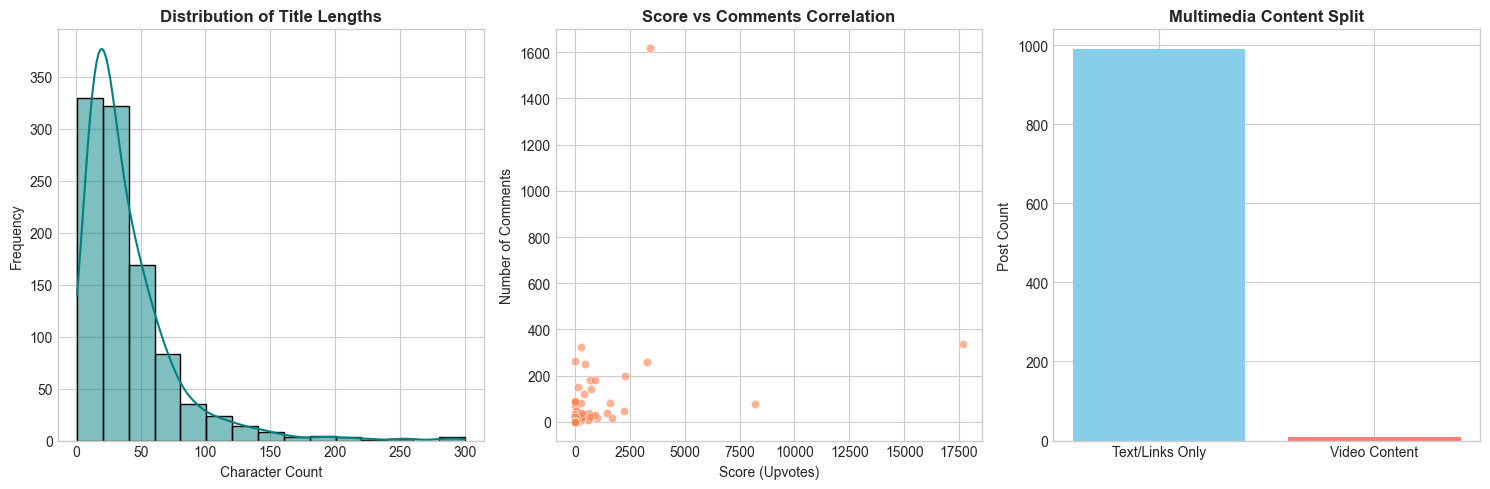

In [4]:
# Create plots to visualize the dataset
import seaborn as sns
import numpy as np

plt.figure(figsize=(15, 5))

# 1. Distribution of Post Title Lengths
plt.subplot(1, 3, 1)
title_lengths = df_submissions['title'].apply(len)
sns.histplot(title_lengths, bins=15, kde=True, color='teal')
plt.title('Distribution of Title Lengths', fontsize=12, fontweight='bold')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

# 2. Score vs Number of Comments Correlation
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_submissions, x='score', y='num_comments', alpha=0.6, color='coral')
plt.title('Score vs Comments Correlation', fontsize=12, fontweight='bold')
plt.xlabel('Score (Upvotes)')
plt.ylabel('Number of Comments')

# 3. Multimedia Availability
plt.subplot(1, 3, 3)
multimedia_counts = df_submissions['is_video'].value_counts()
plt.bar(['Text/Links Only', 'Video Content'], multimedia_counts, color=['skyblue', 'salmon'])
plt.title('Multimedia Content Split', fontsize=12, fontweight='bold')
plt.ylabel('Post Count')

plt.tight_layout()
plt.show()

## 2. Training History & Learning Curves

Plot the training and validation loss (RMSE and MAE) over iterations.

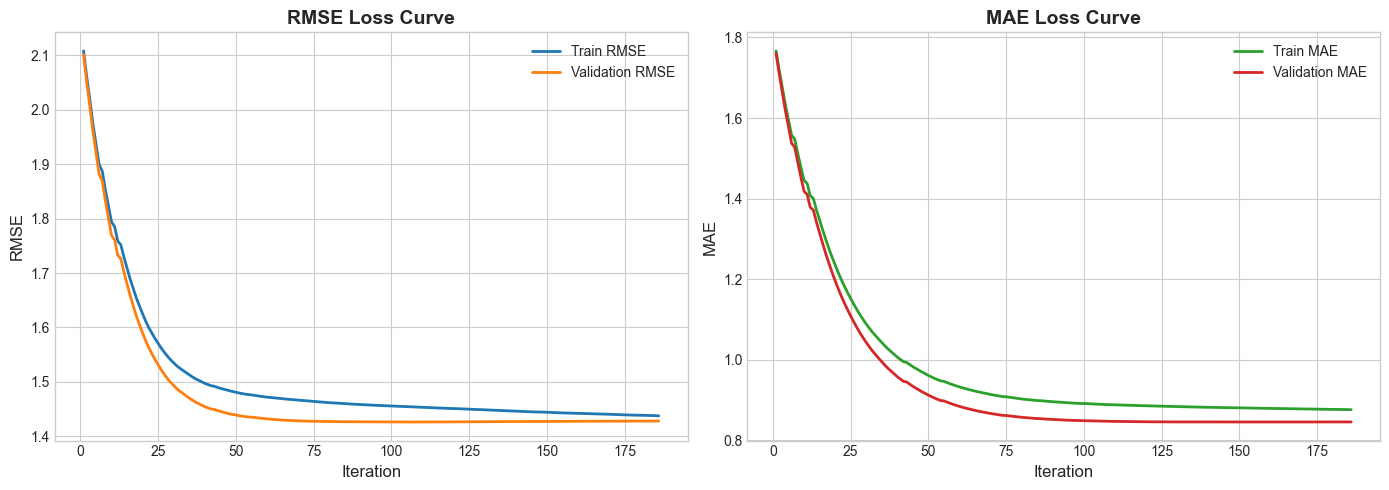

In [5]:
history = summary.get('history', [])
if history:
    iterations = [h['iteration'] for h in history]

    train_rmse = [h.get('train_rmse') for h in history]
    val_rmse = [h.get('validation_rmse') for h in history]

    train_mae = [h.get('train_mae') for h in history]
    val_mae = [h.get('validation_mae') for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot RMSE
    if any(x is not None for x in train_rmse):
        axes[0].plot(iterations, train_rmse, label='Train RMSE', color='#1f77b4', linewidth=2)
    if any(x is not None for x in val_rmse):
        axes[0].plot(iterations, val_rmse, label='Validation RMSE', color='#ff7f0e', linewidth=2)
    axes[0].set_title('RMSE Loss Curve', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('RMSE', fontsize=12)
    axes[0].legend(fontsize=10)

    # Plot MAE
    if any(x is not None for x in train_mae):
        axes[1].plot(iterations, train_mae, label='Train MAE', color='#2ca02c', linewidth=2)
    if any(x is not None for x in val_mae):
        axes[1].plot(iterations, val_mae, label='Validation MAE', color='#d62728', linewidth=2)
    axes[1].set_title('MAE Loss Curve', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Iteration', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].legend(fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No training history found.")

## 3. Feature Importances

Visualize the gain-based importance of each feature in the trained LightGBM model.

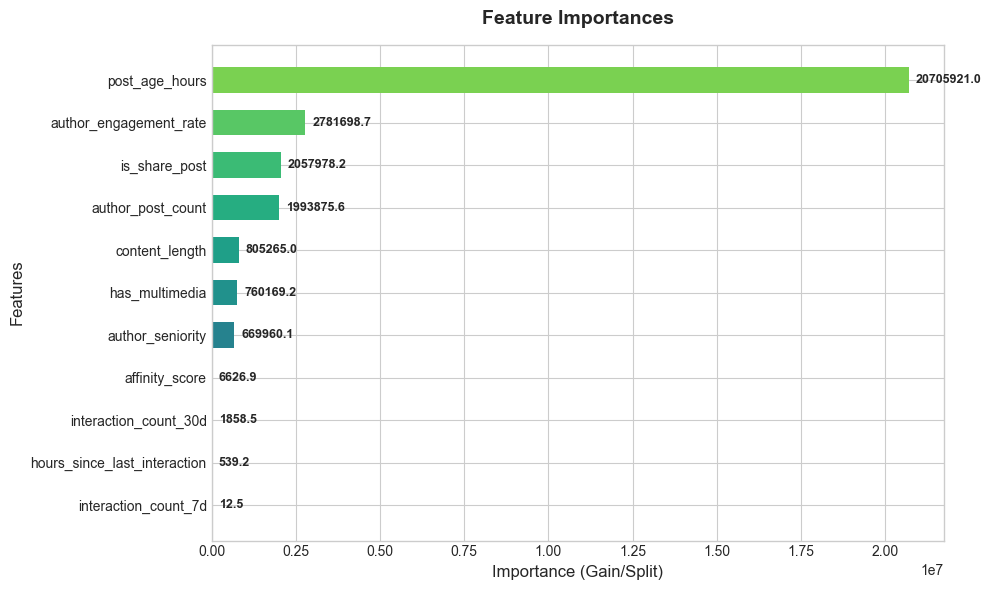

In [6]:
importances = summary.get('feature_importances', {})
if importances:
    sorted_features = sorted(importances.items(), key=lambda x: x[1], reverse=True)
    names = [x[0] for x in sorted_features]
    values = [x[1] for x in sorted_features]

    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(names)))
    bars = plt.barh(names[::-1], values[::-1], color=colors[::-1], height=0.6)

    plt.title('Feature Importances', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Importance (Gain/Split)', fontsize=12)
    plt.ylabel('Features', fontsize=12)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}',
                 va='center', ha='left', fontsize=9, fontweight='semibold')

    plt.tight_layout()
    plt.show()
else:
    print("No feature importances found.")

## 4. Data Filtering Statistics

Visualize the reasons why candidate posts were filtered out during the ingestion process.

Submissions Scanned: 18,310,157
Submissions Filtered: 8,445,428 (46.1%)
Submissions Accepted: 9,864,729 (53.9%)


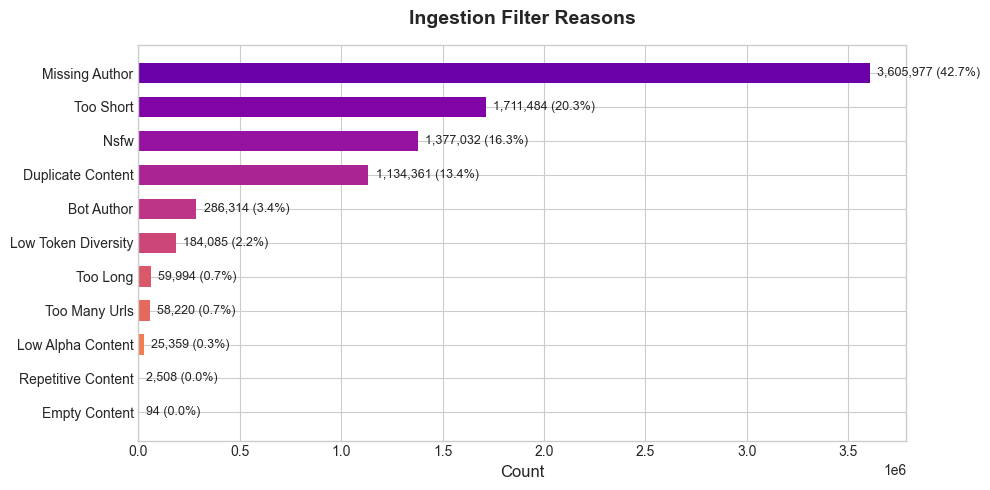

In [7]:
scan_stats = summary.get('scan_stats', {})
if scan_stats:
    scanned = scan_stats.get('submissions_scanned', 0)
    filtered = scan_stats.get('submissions_filtered', 0)
    accepted = scan_stats.get('submissions_accepted', 0)

    print(f"Submissions Scanned: {scanned:,}")
    print(f"Submissions Filtered: {filtered:,} ({filtered/scanned*100:.1f}%)")
    print(f"Submissions Accepted: {accepted:,} ({accepted/scanned*100:.1f}%)")

    reasons = scan_stats.get('filter_reasons', {})
    if reasons:
        sorted_reasons = sorted(reasons.items(), key=lambda x: x[1], reverse=True)
        r_names = [x[0].replace('_', ' ').title() for x in sorted_reasons]
        r_values = [x[1] for x in sorted_reasons]

        plt.figure(figsize=(10, 5))
        colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(r_names)))
        bars = plt.barh(r_names[::-1], r_values[::-1], color=colors[::-1], height=0.6)

        plt.title('Ingestion Filter Reasons', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Count', fontsize=12)

        total_filtered = sum(r_values)
        for bar in bars:
            width = bar.get_width()
            pct = (width / total_filtered * 100) if total_filtered > 0 else 0
            plt.text(width + max(r_values)*0.01, bar.get_y() + bar.get_height()/2,
                     f'{width:,} ({pct:.1f}%)',
                     va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.show()
else:
    print("No scan stats found.")

## 5. Interaction Skipped Statistics

Visualize the reasons why comments/interactions were skipped during the ingestion process.

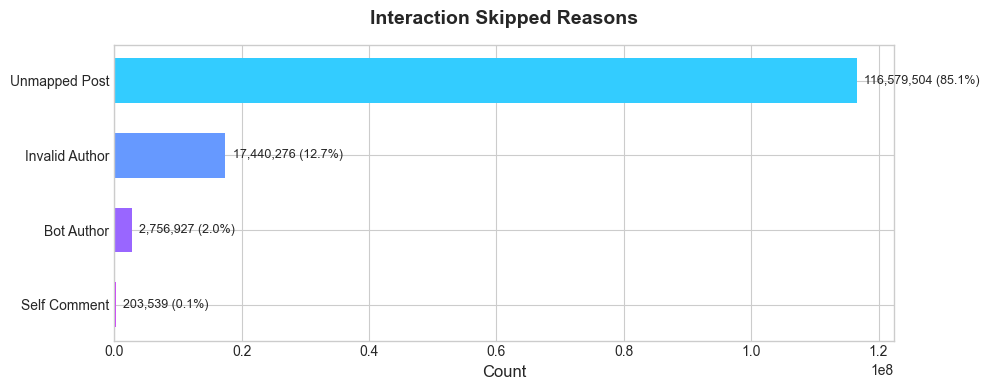

In [8]:
interaction_stats = summary.get('interaction_stats', {})
if interaction_stats:
    reasons = interaction_stats.get('skipped_reasons', {})
    if reasons:
        sorted_reasons = sorted(reasons.items(), key=lambda x: x[1], reverse=True)
        i_names = [x[0].replace('_', ' ').title() for x in sorted_reasons]
        i_values = [x[1] for x in sorted_reasons]

        plt.figure(figsize=(10, 4))
        colors = plt.cm.cool(np.linspace(0.2, 0.8, len(i_names)))
        bars = plt.barh(i_names[::-1], i_values[::-1], color=colors[::-1], height=0.6)

        plt.title('Interaction Skipped Reasons', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Count', fontsize=12)

        total_skipped = sum(i_values)
        for bar in bars:
            width = bar.get_width()
            pct = (width / total_skipped * 100) if total_skipped > 0 else 0
            plt.text(width + max(i_values)*0.01, bar.get_y() + bar.get_height()/2,
                     f'{width:,} ({pct:.1f}%)',
                     va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.show()
else:
    print("No interaction stats found.")

## 6. Model Evaluation Metrics Comparison

Compare metric groups across Train, Validation, and Test datasets.

Metric     | Train      | Validation | Test      
--------------------------------------------------
RMSE       | 1.4545     | 1.4264     | 1.3899    
MAE        | 0.8892     | 0.8475     | 0.8253    
NDCG@K     | 0.9394     | 0.9505     | 0.9574    
R2         | 0.5467     | 0.5627     | 0.5712    
--------------------------------------------------


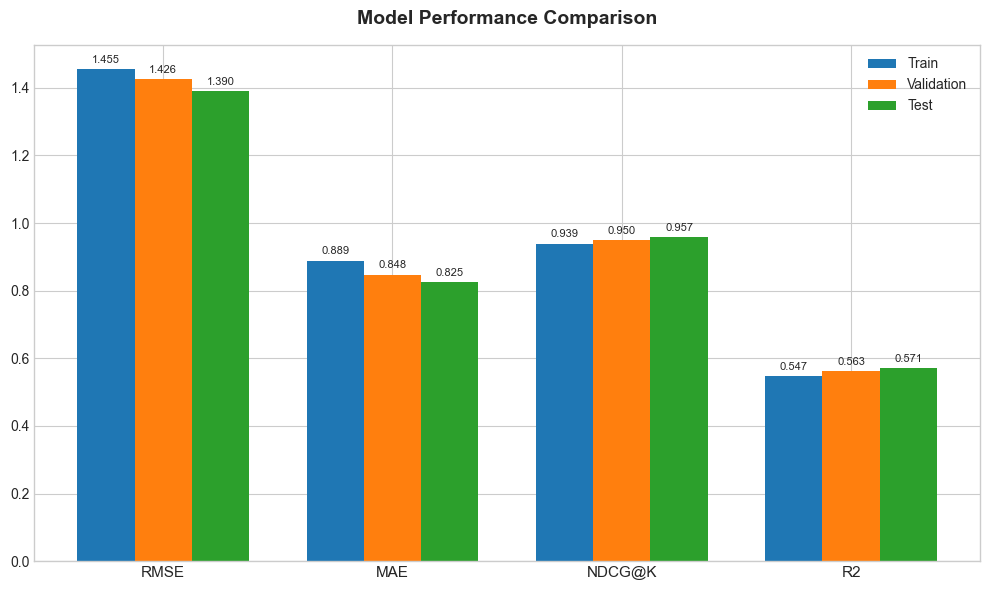

In [9]:
metrics = summary.get('metrics', {})
if metrics:
    metric_groups = {
        'RMSE': (metrics.get('train_rmse'), metrics.get('validation_rmse'), metrics.get('test_rmse')),
        'MAE': (metrics.get('train_mae'), metrics.get('validation_mae'), metrics.get('test_mae')),
        'NDCG@K': (metrics.get('train_ndcg_k'), metrics.get('validation_ndcg_k'), metrics.get('test_ndcg_k')),
        'R2': (metrics.get('train_r2'), metrics.get('validation_r2'), metrics.get('test_r2'))
    }

    print(f"{'Metric':<10} | {'Train':<10} | {'Validation':<10} | {'Test':<10}")
    print("-" * 50)
    for name, vals in metric_groups.items():
        t_val = f"{vals[0]:.4f}" if vals[0] is not None else "N/A"
        v_val = f"{vals[1]:.4f}" if vals[1] is not None else "N/A"
        te_val = f"{vals[2]:.4f}" if vals[2] is not None else "N/A"
        print(f"{name:<10} | {t_val:<10} | {v_val:<10} | {te_val:<10}")
    print("-" * 50)

    labels = list(metric_groups.keys())
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    train_vals = [metric_groups[l][0] or 0.0 for l in labels]
    val_vals = [metric_groups[l][1] or 0.0 for l in labels]
    test_vals = [metric_groups[l][2] or 0.0 for l in labels]

    rects1 = ax.bar(x - width, train_vals, width, label='Train', color='#1f77b4')
    rects2 = ax.bar(x, val_vals, width, label='Validation', color='#ff7f0e')
    rects3 = ax.bar(x + width, test_vals, width, label='Test', color='#2ca02c')

    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend(fontsize=10)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0.0:
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    plt.show()
else:
    print("No metrics found.")